SOCIAL MEDIA TREND ANALYSIS

In [1]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [ ]:
# Load Dataset
df=pd.read_csv("sentimentdataset.csv")

In [6]:
# Display first few rows
df.head()  

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,15-01-2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,15-01-2023 08:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,15-01-2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,15-01-2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,15-01-2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


DATA CLEANING AND TRANSFORMATION

In [7]:
# Check for missing values
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

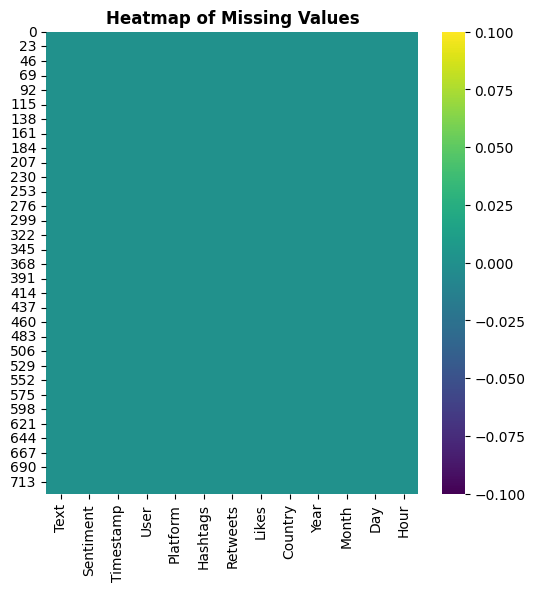

In [38]:
# Visualize missing values
plt.figure(figsize=(6, 6))
sns.heatmap(df.isnull(), cmap="viridis")
plt.title("Heatmap of Missing Values", weight='bold')
plt.show()

In [ ]:
# Clean Data (Drop unnecessary columns)
df=df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors="ignore")
print(df.columns.tolist())

['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [ ]:
# Sentiment Count
sentiment_counts=df["Sentiment"].value_counts()
print(sentiment_counts)

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


In [ ]:
# Filter Tweets by Sentiment
positive_tweets=df[df["Sentiment"].str.strip()=="Positive"]
negative_tweets=df[df["Sentiment"].str.strip()=="Negative"]
neutral_tweets=df[df["Sentiment"].str.strip()=="Neutral"]

In [14]:
positive_tweets.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,15-01-2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
2,Just finished an amazing workout! 💪 ...,Positive,15-01-2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,15-01-2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
5,Feeling grateful for the little things in lif...,Positive,16-01-2023 09:10,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25,50,India,2023,1,16,9
6,Rainy days call for cozy blankets and hot coc...,Positive,16-01-2023 14:45,RainyDays,Facebook,#RainyDays #Cozy,10,20,Canada,2023,1,16,14


In [15]:
negative_tweets.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
1,Traffic was terrible this morning. ...,Negative,15-01-2023 08:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
8,Political discussions heating up on the timel...,Negative,17-01-2023 08:00,DebateTalk,Twitter,#Politics #Debate,30,60,USA,2023,1,17,8
11,Feeling a bit under the weather today. ...,Negative,18-01-2023 10:30,WellnessCheck,Twitter,#SickDay #Health,7,15,Canada,2023,1,18,10
19,Winter blues got me feeling low. ...,Negative,20-01-2023 15:15,WinterBlues,Instagram,#WinterBlues #Mood,8,15,USA,2023,1,20,15


In [16]:
neutral_tweets.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
4,Trying out a new recipe for dinner tonight. ...,Neutral,15-01-2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
9,Missing summer vibes and beach days. ...,Neutral,17-01-2023 12:20,BeachLover,Facebook,#Summer #BeachDays,18,35,Australia,2023,1,17,12
14,Technology is changing the way we live. ...,Neutral,19-01-2023 09:45,TechEnthusiast,Twitter,#Tech #Innovation,15,30,India,2023,1,19,9
18,Attending a virtual conference on AI. ...,Neutral,20-01-2023 11:30,TechConference,Facebook,#AI #TechConference,25,50,USA,2023,1,20,11
704,Trying out a new study technique for upcoming ...,Neutral,02-10-2023 16:45,StudyTechniqueExperimentHighSchool,Instagram,#StudyStrategies #HighSchoolExams,23,42,USA,2023,10,2,16


In [ ]:
# Top Hashtags
hashtags=df["Hashtags"].dropna().str.split()
hashtags_flat=[tag for sublist in hashtags for tag in sublist]
hashtags_counter=Counter(hashtags_flat)

top_hashtags=pd.Series(dict(hashtags_counter)).sort_values(ascending=False).head(10)
print(top_hashtags)


#Serenity       15
#Gratitude      13
#Excitement     13
#Despair        11
#Nostalgia      11
#Contentment    10
#Curiosity      10
#Loneliness      9
#Hopeful         9
#Awe             9
dtype: int64


In [18]:
#  Most Liked Posts
print(df.nlargest(10, "Likes")[["Text", "Likes"]])

                                                  Text  Likes
335  Thrilled to witness the grandeur of a cultural...     80
345  Motivated to achieve fitness goals after an in...     80
355  Anticipation for an upcoming adventure in an e...     80
368  Elation over discovering a rare book in a quai...     80
382  A sense of wonder at the vastness of the cosmo...     80
402  Awe-inspired by the vastness of the cosmos on ...     80
432  Heartache deepens, a solitary journey through ...     80
470  Dancing on sunshine, each step a celebration o...     80
481  Surrounded by the colors of joy, a canvas pain...     80
510  At the front row of Adele's concert, each note...     80


In [19]:
# Average Likes and Retweets per Sentiment
print(df.groupby("Sentiment")[["Likes", "Retweets"]].mean())

                      Likes   Retweets
Sentiment                             
Acceptance        35.000000  17.333333
Acceptance        33.600000  16.800000
Accomplishment    51.666667  26.000000
Admiration        45.000000  22.000000
Admiration        40.000000  20.000000
...                     ...        ...
Wonder            80.000000  40.000000
Wonder            80.000000  40.000000
Wonderment        70.000000  35.000000
Yearning          20.000000  10.000000
Zest              31.000000  15.500000

[279 rows x 2 columns]


In [20]:
# Top Users and Platforms
print(df["User"].value_counts().head(5))  # Top 5 users
print(df["Platform"].value_counts())      # Most used platforms

User
RainNurturer        3
PeakConqueror       3
WindWhisperer       3
CarnivalDreamer     3
DawnGardener        3
Name: count, dtype: int64
Platform
Instagram     258
Facebook      231
Twitter       128
Twitter       115
Name: count, dtype: int64


In [ ]:
# Sentiment Trends Over Time
sentiment_trends=df.groupby(["Year", "Month"])["Sentiment"].value_counts().unstack()
sentiment_trends.head()

Sentiment   Acceptance     Acceptance        Accomplishment   Admiration   \
Year Month                                                                  
2010 5                NaN               NaN              NaN          NaN   
     8                NaN               NaN              NaN          NaN   
     11               NaN               NaN              NaN          NaN   
2011 6                NaN               NaN              NaN          NaN   
     7                NaN               NaN              NaN          NaN   

Sentiment   Admiration     Admiration      Adoration      Adrenaline       \
Year Month                                                                  
2010 5                NaN             NaN            NaN              NaN   
     8                NaN             NaN            NaN              NaN   
     11               NaN             NaN            NaN              NaN   
2011 6                NaN             NaN            NaN              NaN   
     7                NaN             NaN            NaN              NaN   

Sentiment   Adventure   Affection      ...  Vibrancy   Whimsy          \
Year Month                             ...                              
2010 5             NaN            NaN  ...        NaN             NaN   
     8             NaN            NaN  ...        NaN             NaN   
     11            NaN            NaN  ...        NaN             NaN   
2011 6             NaN            NaN  ...        NaN             NaN   
     7             NaN            NaN  ...        NaN             NaN   

Sentiment   Whispers of the Past   Winter Magic   Wonder   Wonder       \
Year Month                                                               
2010 5                        NaN            NaN      NaN          NaN   
     8                        NaN            NaN      NaN          NaN   
     11                       NaN            NaN      NaN          NaN   
2011 6                        NaN            NaN      NaN          NaN   
     7                        NaN            NaN      NaN          NaN   

Sentiment   Wonder         Wonderment      Yearning   Zest   
Year Month                                                   
2010 5                NaN             NaN        NaN    NaN  
     8                NaN             NaN        NaN    NaN  
     11               NaN             NaN        NaN    NaN  
2011 6                NaN             NaN        NaN    NaN  
     7                NaN             NaN        NaN    NaN  

[5 rows x 279 columns]

CREATE DIFFERENT TYPES OF VISUALIZATION

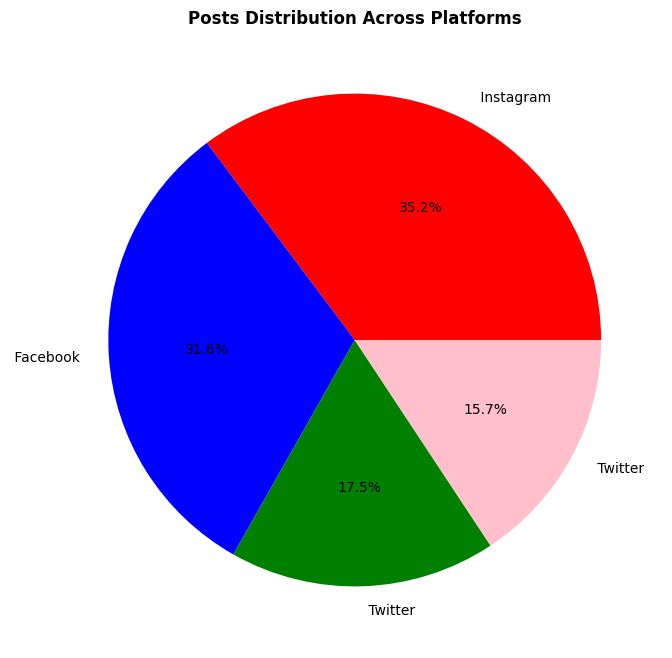

In [24]:
# Posts per Platform 
plt.figure(figsize=(8,8))
df["Platform"].value_counts().plot(kind="pie", autopct='%1.1f%%', colors=["red", "blue", "green", "pink"])
plt.title("Posts Distribution Across Platforms", fontweight='bold')
plt.ylabel("")
plt.show()

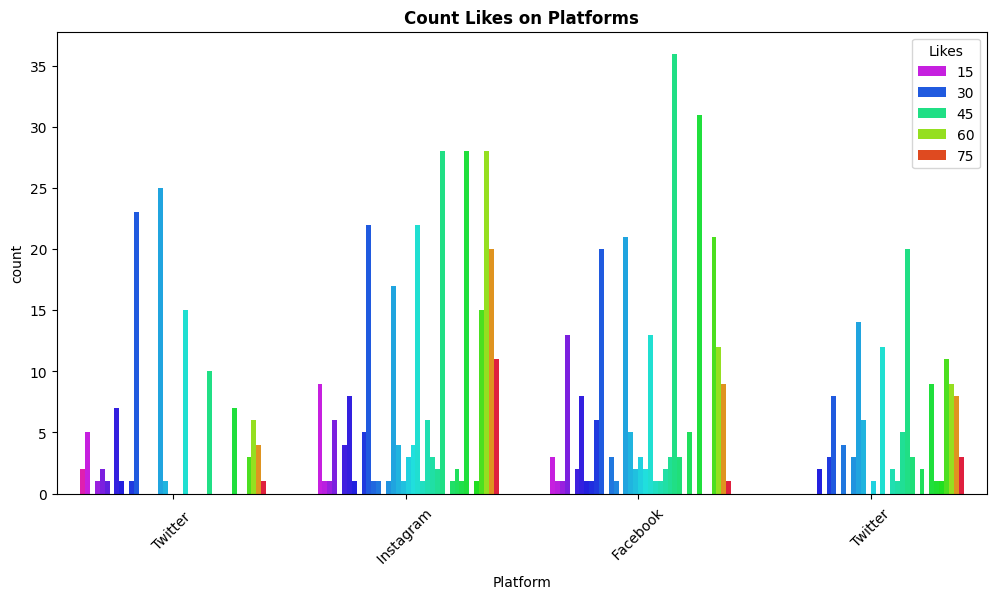

In [25]:
# Likes on Different Platforms
plt.figure(figsize=(12,6))
sns.countplot(x="Platform", data=df, hue="Likes", palette="gist_rainbow_r")
plt.title("Count Likes on Platforms", fontweight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.show()

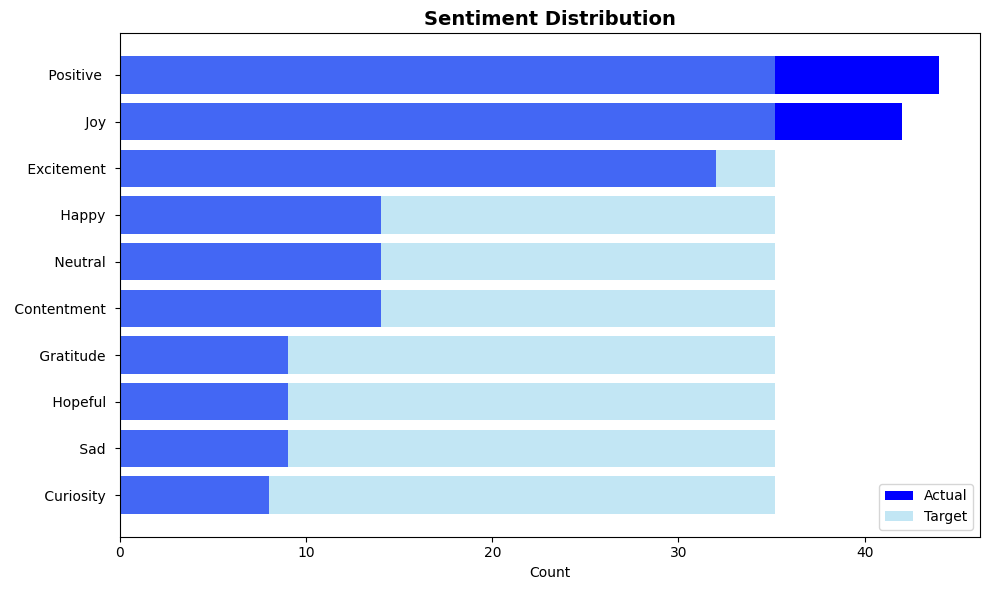

In [39]:
#  Sentiment Count with Target
sentiment_counts_sorted=sentiment_counts.sort_values(ascending=True).tail(10)
targets=[sentiment_counts_sorted.max() * 0.8] * len(sentiment_counts_sorted)

fig, ax=plt.subplots(figsize=(10, 6))
ax.barh(sentiment_counts_sorted.index, sentiment_counts_sorted.values, color="blue", label="Actual")
ax.barh(sentiment_counts_sorted.index, targets, color="skyblue", alpha=0.5, label="Target")
ax.set_xlabel("Count")
ax.set_title("Sentiment Distribution", fontsize=14, weight='bold')
ax.legend()
plt.tight_layout()
plt.show()


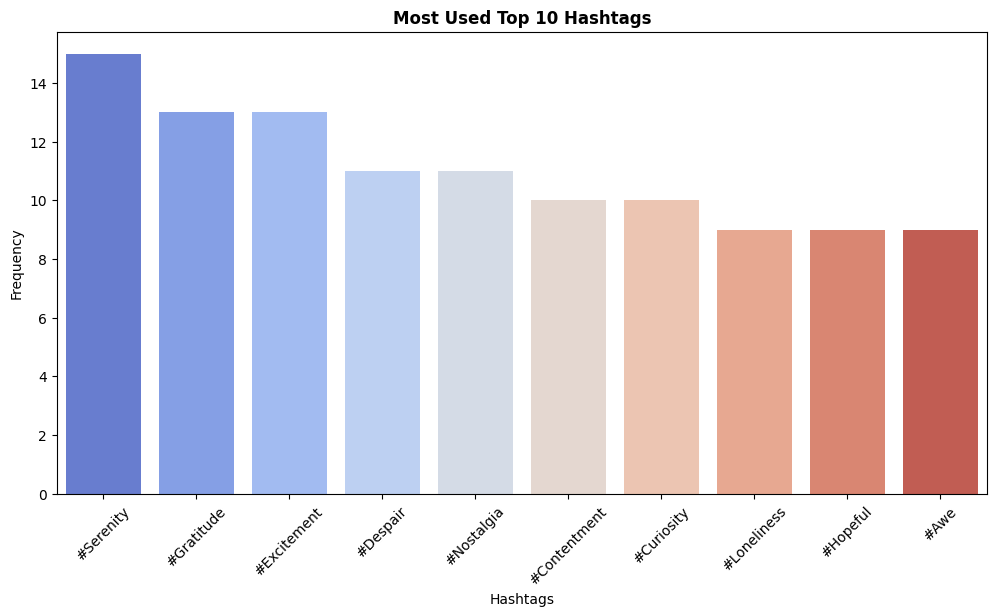

In [32]:
# Most Used Hashtags
plt.figure(figsize=(12,6))
sns.barplot(x=top_hashtags.index, y=top_hashtags.values, hue=top_hashtags.index, palette="coolwarm", legend=False)
plt.title("Most Used Top 10 Hashtags", fontweight='bold')
plt.xlabel("Hashtags")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

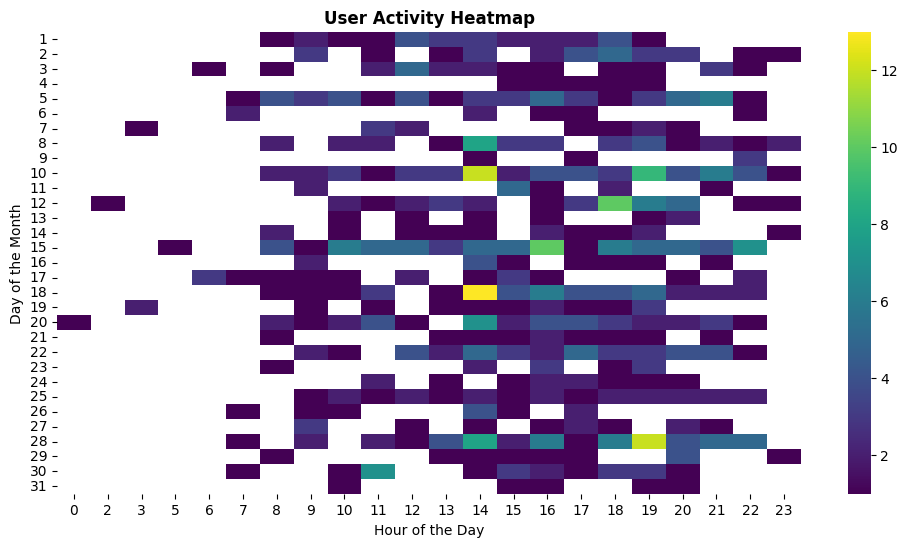

In [40]:
#  User Activity Heatmap
activity_pivot=df.pivot_table(index="Day", columns="Hour", values="User", aggfunc="count")

plt.figure(figsize=(12,6))
sns.heatmap(activity_pivot, cmap="viridis", annot=False)
plt.title("User Activity Heatmap", weight='bold')
plt.xlabel("Hour of the Day")
plt.ylabel("Day of the Month")
plt.show()

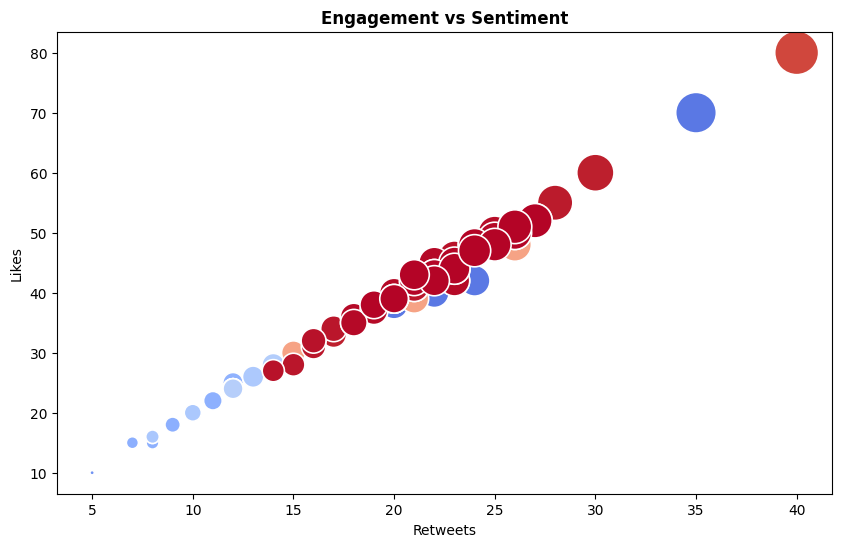

In [41]:
# Engagement vs Sentiment 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Retweets", y="Likes", hue="Sentiment", size=df["Likes"] + df["Retweets"], sizes=(10, 1000), data=df, palette="coolwarm", legend=False)
plt.title("Engagement vs Sentiment", weight='bold')
plt.xlabel("Retweets")
plt.ylabel("Likes")
plt.show()

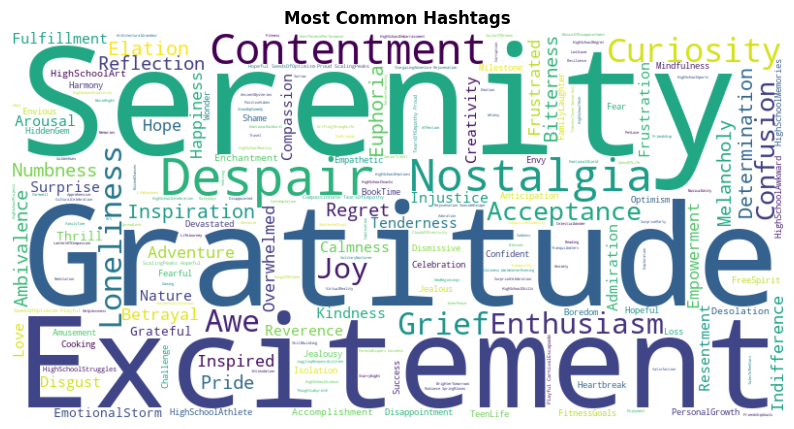

In [42]:
# WordCloud of Hashtags
wordcloud=WordCloud(width=800, height=400, background_color="white").generate(" ".join(hashtags_flat))

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Hashtags", weight='bold')
plt.show()